# Timerseries Analysis

In [1]:
!pip install numpy pandas scikit-learn matplotlib tqdm stumpy tslearn

In [2]:
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tslearn.shapelets import LearningShapelets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import glob
from sklearn.cluster import KMeans
from typing import Optional, List, Dict
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from tqdm import tqdm
import stumpy

2025-12-31 17:13:32.797910: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-31 17:13:32.808275: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-31 17:13:33.174253: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-31 17:13:34.435856: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

## Load Audio and Extract Features

Load each file, trim, normalize amplitude, beattrack and then extract features.

In [3]:
def extract_beat_sync_features(
    mp3_path: str,
    sr: int = 22050,
    trim_db: int = 25,
    hop_length: int = 512,
    n_mfcc: int = 13,
) -> dict:
    y, sr = librosa.load(mp3_path, sr=sr, mono=True)
    y, _ = librosa.effects.trim(y, top_db=trim_db)

    # normalize by peak amplitude
    peak = np.max(np.abs(y)) + 1e-9
    y = y / peak

    duration = librosa.get_duration(y=y, sr=sr)

    # beat tracking
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    tempo, beat_frames = librosa.beat.beat_track(
        onset_envelope=onset_env, sr=sr, hop_length=hop_length
    )
    if len(beat_frames) < 2:
        # fallback: if beat tracking fails, treat it like one "beat" at start
        beat_frames = np.array([0], dtype=int)

    beat_times = librosa.frames_to_time(
        beat_frames, sr=sr, hop_length=hop_length
    )

    # frame-level features
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length
    )  # (n_mfcc, n_frames)

    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, hop_length=hop_length
    )  # (12, n_frames)

    # use the same onset envelope as a 1D rhythmic/dynamic feature
    onset = onset_env.reshape(1, -1)  # (1, n_frames)

    # beat-synchronous aggregation (median is robust)
    mfcc_bs = librosa.util.sync(mfcc, beat_frames, aggregate=np.median).T
    chroma_bs = librosa.util.sync(chroma, beat_frames, aggregate=np.median).T
    onset_bs = librosa.util.sync(onset, beat_frames, aggregate=np.median).T

    return {
        "mfcc_bs": mfcc_bs,
        "chroma_bs": chroma_bs,
        "onset_bs": onset_bs,
        "tempo": float(tempo),
        "beat_times": beat_times,
        "duration": float(duration),
    }

audio_features = []
files = sorted(glob.glob("./fedez_fibra/*.mp3"))
for mp3_path in tqdm(files):
    out = extract_beat_sync_features(mp3_path)
    out["artist"] = mp3_path.split(" ")[0].split("/")[-1]
    audio_features.append(out)

pd.DataFrame(audio_features).head()

  0%|                                                                                                    | 0/454 [00:00<?, ?it/s]/tmp/ipykernel_76017/1533908542.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "tempo": float(tempo),
100%|██████████████████████████████████████████████████████████████████████████████████████████| 454/454 [06:02<00:00,  1.25it/s]


,mfcc_bs,chroma_bs,onset_bs,tempo,beat_times,duration,artist
0,"[[-350.31302, 91.51345, 13.632151, 17.82575, 1...","[[0.4387267, 0.38372955, 0.24992846, 0.4454900...","[[0.3700192], [0.50319743], [0.6125634], [0.62...",89.102909,"[1.0913378684807256, 1.787936507936508, 2.4613...",119.675646,ART07024718
1,"[[-242.33176, 70.25562, 21.659698, -4.7515182,...","[[0.22477448, 0.41218668, 0.20322362, 0.043952...","[[1.5244014], [1.0129036], [1.3447752], [1.203...",123.046875,"[2.507755102040816, 2.995374149659864, 3.50621...",122.694240,ART07024718
2,"[[-59.30336, 49.99316, 17.60097, 12.012688, -3...","[[0.33985, 0.34022716, 0.36318263, 0.8739895, ...","[[0.0], [0.8429301], [0.9664587], [1.4517419],...",123.046875,"[0.06965986394557823, 0.5572789115646258, 1.04...",185.527438,ART07024718
3,"[[-52.306366, 85.76689, -3.7307653, 64.84314, ...","[[1.0, 0.82550794, 0.7445236, 0.6228192, 0.483...","[[0.0], [0.31376696], [0.284397], [0.33596697]...",92.285156,"[0.06965986394557823, 0.8591383219954648, 1.50...",181.998005,ART07024718
4,"[[-142.62172, 22.849407, -68.81631, 13.575657,...","[[0.342247, 0.34331116, 0.4847732, 0.82623506,...","[[0.0], [0.5330395], [0.54297155], [0.2990342]...",129.199219,"[0.06965986394557823, 0.5340589569160997, 0.99...",196.742676,ART07024718


## Feature Aggregation for Clustering

We aggregate the features extracted in the previous step into a single fixed-length feature vector per song. This allows for clustering the songs without the need to use DTW or subsequences.

Selected aggregated features per song:

- Basic track/tempo descriptors
  - duration: total length in seconds
  - tempo: estimated BPM from beat tracking
  - n_beats: number of detected beats (rough proxy for song length / beat density)

- MFCC statistics (timbre / production / "color")
  - mfcc_mean_*: mean of each MFCC coefficient across beats
  - mfcc_std_*: standard deviation of each MFCC coefficient across beats
  - mfcc_var_mean: average variance across MFCC coefficients (overall timbre variability)

- Chroma statistics (tonality / harmonic content distribution)
  - chroma_mean_*: average energy for each pitch class (12 dimensions)
  - chroma_std_*: variability of each pitch class across beats
  - chroma_entropy: entropy of the normalized chroma mean vector
    (higher = more evenly spread pitch classes; lower = more dominated by a few)
  - chroma_max_frac: fraction of energy in the most dominant pitch class

- Onset strength statistics (rhythmic density / dynamic “punch”)
  - onset_mean: average and variability of beat-synchronous onset strength
  - onset_std: average and variability of beat-synchronous onset strength
  - onset_p95: 95th percentile (captures strong accent peaks)
  - onset_peakiness: ratio p95 / mean (how “spiky” the accents are)
  - onset_diff_mean: mean / 95th percentile of absolute beat-to-beat
    changes in onset strength (proxy for structural/dynamic changes)

In [4]:
def summarize_song_features(out: dict) -> dict:
    mfcc = out["mfcc_bs"]          # (T, n_mfcc)
    chroma = out["chroma_bs"]      # (T, 12)
    onset = out["onset_bs"][:, 0]  # (T,)

    eps = 1e-9

    agg = {}
    agg["artist"] = out["artist"]
    agg["tempo"] = out["tempo"]
    agg["duration"] = out["duration"]
    agg["n_beats"] = float(mfcc.shape[0])

    # mean and std per coefficient
    mfcc_mean = mfcc.mean(axis=0)
    mfcc_std = mfcc.std(axis=0)
    for i, v in enumerate(mfcc_mean, start=1):
        agg[f"mfcc_mean_{i:02d}"] = float(v)
    for i, v in enumerate(mfcc_std, start=1):
        agg[f"mfcc_std_{i:02d}"] = float(v)

    agg["mfcc_var_mean"] = float(np.mean(mfcc_std**2))

    chroma_mean = chroma.mean(axis=0)
    chroma_std = chroma.std(axis=0)

    # normalize chroma_mean to a distribution for entropy-like features
    p = chroma_mean / (chroma_mean.sum() + eps)

    for k, v in enumerate(chroma_mean):
        agg[f"chroma_mean_{k:02d}"] = float(v)
    for k, v in enumerate(chroma_std):
        agg[f"chroma_std_{k:02d}"] = float(v)

    agg["chroma_entropy"] = float(-(p * np.log(p + eps)).sum())
    agg["chroma_max_frac"] = float(p.max())  # dominance of one pitch class

    # Onset strength summary stats (rhythm / dynamics proxy)
    agg["onset_mean"] = float(onset.mean())
    agg["onset_std"] = float(onset.std())
    agg["onset_p95"] = float(np.percentile(onset, 95))
    agg["onset_peakiness"] = float(
        np.percentile(onset, 95) / (onset.mean() + eps)
    )

    # simple "section change" proxy: how often onset changes sharply beat-to-beat
    diff = np.abs(np.diff(onset))
    agg["onset_diff_mean"] = float(diff.mean()) if diff.size else 0.0
    agg["onset_diff_p95"] = float(np.percentile(diff, 95)) if diff.size else 0.0

    return agg


# extract aggregated metadata features for all songs
agg_rows = []
for out in audio_features:
    agg_rows.append(summarize_song_features(out))

df = pd.DataFrame(agg_rows)
og_df = df.copy(deep=True)
df = df.drop(columns=["artist"])

print(df.shape)
pd.set_option('display.max_columns', None)
df.head()

(454, 62)


,tempo,duration,n_beats,mfcc_mean_01,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_05,mfcc_mean_06,mfcc_mean_07,mfcc_mean_08,mfcc_mean_09,mfcc_mean_10,mfcc_mean_11,mfcc_mean_12,mfcc_mean_13,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_04,mfcc_std_05,mfcc_std_06,mfcc_std_07,mfcc_std_08,mfcc_std_09,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_02,chroma_mean_03,chroma_mean_04,chroma_mean_05,chroma_mean_06,chroma_mean_07,chroma_mean_08,chroma_mean_09,chroma_mean_10,chroma_mean_11,chroma_std_00,chroma_std_01,chroma_std_02,chroma_std_03,chroma_std_04,chroma_std_05,chroma_std_06,chroma_std_07,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_entropy,chroma_max_frac,onset_mean,onset_std,onset_p95,onset_peakiness,onset_diff_mean,onset_diff_p95
0,89.102909,119.675646,175.0,-158.168915,103.729576,3.666087,38.286690,6.462377,17.200384,-9.020932,8.186444,-15.491856,12.498502,-3.951239,-0.101257,-5.834316,106.947586,20.744963,15.191678,13.263687,10.978548,8.240154,9.611195,7.740864,9.499741,7.823032,5.332959,6.590291,5.685448,990.093750,0.222746,0.205942,0.216175,0.316212,0.504544,0.347253,0.316143,0.431757,0.379747,0.411046,0.306597,0.272804,0.149091,0.148490,0.129447,0.162394,0.253724,0.173641,0.168443,0.240155,0.171074,0.245911,0.137189,0.132367,2.448570,0.128351,1.026717,0.360128,1.549208,1.508895,0.209277,0.556716
1,123.046875,122.694240,243.0,-51.307949,94.274475,-10.893713,10.078120,5.699719,5.601115,-5.013778,3.204492,-5.247590,1.615436,-2.062113,1.850235,1.923126,42.064415,18.266651,14.100111,13.038759,13.833111,9.725368,8.494979,8.429314,6.369574,6.134578,5.792819,5.792889,6.600730,237.688614,0.388347,0.472805,0.524635,0.471819,0.435879,0.364299,0.319499,0.312314,0.373174,0.363408,0.398952,0.410998,0.142900,0.192324,0.205464,0.179194,0.179943,0.163741,0.153971,0.150786,0.196918,0.181945,0.191594,0.165256,2.473500,0.108482,1.307706,0.356755,1.850940,1.415410,0.290918,0.727805
2,123.046875,185.527438,364.0,-63.896324,82.414986,-1.491515,8.552964,6.751057,5.475074,-5.372694,2.871174,-5.015740,2.478053,-4.113450,1.432435,-3.011875,95.649117,24.659386,22.954193,13.523682,15.784091,11.420725,9.411446,11.458076,8.550924,7.960244,7.538289,7.624222,9.029694,876.848572,0.404990,0.417858,0.417417,0.429843,0.455879,0.386755,0.320775,0.366050,0.387638,0.457095,0.441335,0.409223,0.196240,0.200238,0.206617,0.205386,0.215845,0.181878,0.158671,0.181558,0.191228,0.258999,0.230848,0.194442,2.480602,0.093383,1.067507,0.340703,1.563847,1.464953,0.230953,0.711033
3,92.285156,181.998005,251.0,-12.326178,89.520203,-3.961414,30.572601,11.225278,11.424213,-2.725905,7.167484,-1.636662,6.239148,-2.517207,5.088518,-0.525433,51.730137,16.901814,12.708160,10.817780,9.264806,6.702596,6.865829,6.242379,6.102638,6.775903,5.746853,5.209935,4.239801,278.336090,0.360818,0.319289,0.433231,0.307337,0.299752,0.390453,0.307364,0.303901,0.290493,0.399368,0.518921,0.349244,0.228451,0.161131,0.246348,0.170704,0.151589,0.235229,0.164671,0.196473,0.157645,0.191880,0.287599,0.167687,2.468838,0.121238,0.928150,0.206752,1.219235,1.313618,0.156321,0.425156
4,129.199219,196.742676,356.0,-30.351585,69.020241,-4.350805,23.973257,8.916329,-4.661335,-3.560339,3.058528,-2.507048,4.128809,-1.376578,4.342422,1.433885,51.285381,16.148563,23.267908,12.147523,10.354442,14.248526,8.970078,6.350778,8.648898,7.430833,6.105474,7.238555,5.827940,328.047150,0.400180,0.407072,0.418192,0.521001,0.374701,0.316217,0.409472,0.345433,0.392402,0.342894,0.434325,0.523048,0.153682,0.201147,0.165594,0.226660,0.179769,0.151891,0.231444,0.162972,0.204666,0.161959,0.196356,0.249653,2.473906,0.107074,1.095254,0.333483,1.683079,1.536702,0.246248,0.824179


## Impute Missing Values

In [5]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median())

## Scale Features

In [6]:
def scale_cols(
    df: pd.DataFrame,
    num_cols: Optional[List[str]],
    cat_cols: Optional[List[str]],
    bool_cols: Optional[List[str]] = None,
) -> pd.DataFrame:
    df = df.copy(deep=True)
    if num_cols:
        df[num_cols] = StandardScaler().fit_transform(df[num_cols])
    if cat_cols:
        df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform)
    if bool_cols:
        df[bool_cols] = df[bool_cols].apply(LabelEncoder().fit_transform)
    return df

df = scale_cols(df, list(df.columns), None, None)
df.head()

,tempo,duration,n_beats,mfcc_mean_01,mfcc_mean_02,mfcc_mean_03,mfcc_mean_04,mfcc_mean_05,mfcc_mean_06,mfcc_mean_07,mfcc_mean_08,mfcc_mean_09,mfcc_mean_10,mfcc_mean_11,mfcc_mean_12,mfcc_mean_13,mfcc_std_01,mfcc_std_02,mfcc_std_03,mfcc_std_04,mfcc_std_05,mfcc_std_06,mfcc_std_07,mfcc_std_08,mfcc_std_09,mfcc_std_10,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_var_mean,chroma_mean_00,chroma_mean_01,chroma_mean_02,chroma_mean_03,chroma_mean_04,chroma_mean_05,chroma_mean_06,chroma_mean_07,chroma_mean_08,chroma_mean_09,chroma_mean_10,chroma_mean_11,chroma_std_00,chroma_std_01,chroma_std_02,chroma_std_03,chroma_std_04,chroma_std_05,chroma_std_06,chroma_std_07,chroma_std_08,chroma_std_09,chroma_std_10,chroma_std_11,chroma_entropy,chroma_max_frac,onset_mean,onset_std,onset_p95,onset_peakiness,onset_diff_mean,onset_diff_p95
0,-1.372933,-1.311194,-1.467811,-2.616617,1.220370,-0.111946,2.405636,0.004397,1.052273,-1.588190,0.638394,-3.597277,2.229174,-0.673897,-1.608932,-1.554282,2.230493,-0.183968,-0.354005,0.147081,-0.256069,-0.219258,0.621877,0.033118,1.565029,0.746186,-1.174648,0.460211,-0.003016,2.270990,-1.907109,-1.994453,-1.835521,-0.582069,1.404493,-0.162914,-0.486326,0.535479,-0.156799,-0.137025,-1.135938,-1.550185,-1.251632,-0.906616,-1.457943,-0.611828,1.171893,-0.438203,-0.387893,0.856077,-0.645358,0.687926,-1.531482,-1.672366,-0.715555,0.745732,-0.837105,1.065299,-0.413684,0.637070,-0.835664,-0.847445
1,0.166795,-1.267231,-1.044100,0.212251,0.665271,-1.211060,-1.198794,-0.116912,-0.865667,-0.740967,-0.549784,-1.007348,-0.570569,-0.088755,-0.946613,0.858024,-0.653700,-0.570600,-0.550743,0.067873,0.857186,0.398329,-0.006105,0.392842,-0.374586,-0.470976,-0.837871,-0.109011,0.810940,-0.675263,-0.190078,1.156490,1.690601,1.102625,0.617121,0.034543,-0.445924,-0.762531,-0.228378,-0.612166,-0.159529,0.028034,-1.376895,0.146228,0.165473,-0.211710,-0.440126,-0.641470,-0.716720,-1.092038,-0.032607,-0.690592,-0.193587,-0.850629,0.535743,-0.462076,1.669103,1.011189,1.385677,-0.324320,0.505328,0.276957
2,0.166795,-0.352124,-0.290142,-0.120994,-0.030987,-0.501291,-1.393675,0.050315,-0.886508,-0.816851,-0.629280,-0.948732,-0.348655,-0.724140,-1.088410,-0.676597,1.728252,0.426706,1.045066,0.238637,1.618053,1.103298,0.509498,1.975412,0.977093,0.845098,0.440419,1.198278,2.971003,1.827547,-0.017516,0.507707,0.464956,0.648166,0.846451,0.294659,-0.430569,-0.178572,-0.070877,0.322272,0.288548,0.007763,-0.297631,0.336320,0.190086,0.412097,0.344285,-0.269086,-0.609929,-0.421258,-0.167493,0.969984,0.771712,-0.121400,0.892214,-1.379967,-0.473292,0.753688,-0.326385,0.185175,-0.479628,0.166731
3,-1.228584,-0.403527,-0.994251,1.244192,0.386152,-0.687743,1.419946,0.761988,0.097182,-0.257247,0.395375,-0.094442,0.618912,-0.229717,0.152432,0.096604,-0.224038,-0.783523,-0.801621,-0.714238,-0.924415,-0.858611,-0.922662,-0.749860,-0.539993,-0.008662,-0.871534,-0.525150,-1.288620,-0.516096,-0.475506,-0.656132,0.645727,-0.678150,-0.943830,0.337499,-0.592010,-0.853956,-1.128701,-0.253500,1.108813,-0.677220,0.354107,-0.603007,1.038581,-0.413913,-1.059625,0.826327,-0.473589,-0.096129,-0.963749,-0.476477,2.167295,-0.789879,0.301766,0.313353,-1.716244,-1.395066,-2.381454,-1.371132,-1.705475,-1.712060
4,0.445871,-0.188785,-0.339990,0.767016,-0.817378,-0.717138,0.576697,0.394725,-2.562565,-0.433669,-0.584596,-0.314491,0.076013,0.123584,-0.100787,0.705886,-0.243808,-0.901034,1.101608,-0.245973,-0.499466,2.279165,0.261185,-0.693221,1.037803,0.463460,-0.608899,0.922971,0.123702,-0.321439,-0.067385,0.380348,0.473814,1.635098,-0.084396,-0.522415,0.637148,-0.402621,-0.018996,-0.816773,0.214437,1.307681,-1.158730,0.358157,-0.686008,0.918781,-0.443925,-0.884780,1.043653,-0.826405,0.151100,-1.121305,-0.076490,1.258066,0.556123,-0.547709,-0.225803,0.637864,0.384649,0.923030,-0.228405,0.910332


## Clustering

We split between the artists (ART07024718, ) and cluster using k-means. The same procedure as for the other dataset is used.

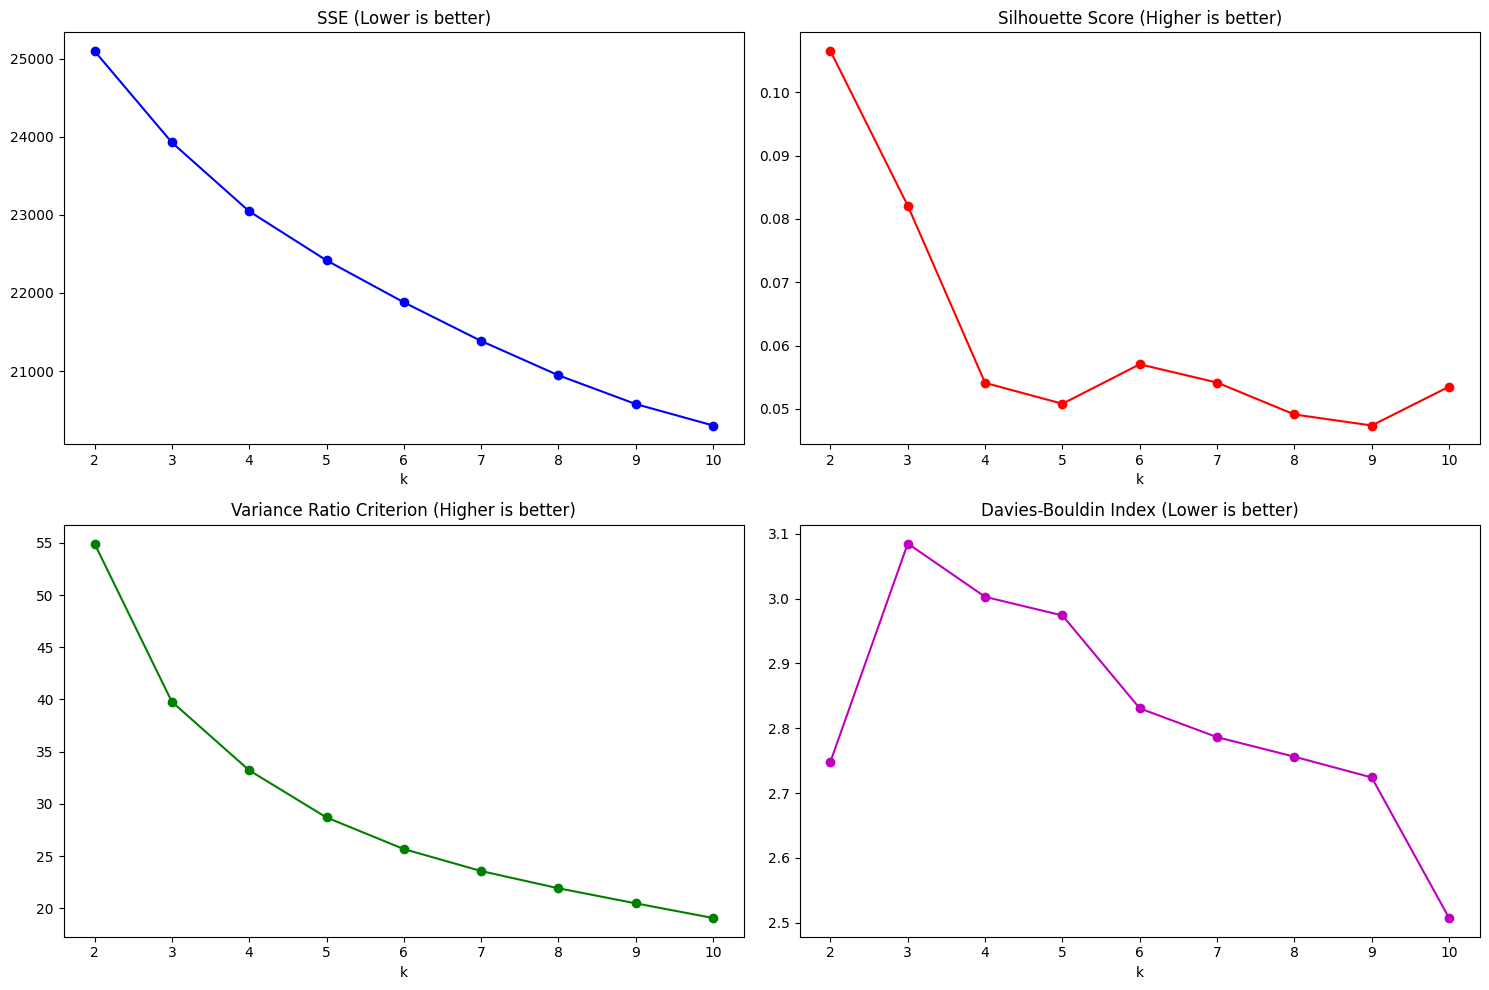

In [7]:
metrics = {
    'sse': [], # Sum of Squared Errors
    'silhouette': [],
    'vrc': [], # Variance Ratio Criterion; Calinski, Harabasz
    'davies_bouldin': []
}
results = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=100)
    labels = kmeans.fit_predict(df)
    results[k] = labels

    metrics['sse'].append(kmeans.inertia_)
    metrics['silhouette'].append(silhouette_score(df.values, labels))
    metrics['vrc'].append(calinski_harabasz_score(df.values, labels))
    metrics['davies_bouldin'].append(davies_bouldin_score(df.values, labels))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
k_range = range(2, 11)

axes[0,0].plot(k_range, metrics['sse'], 'bo-')
axes[0,0].set_title('SSE (Lower is better)')
axes[0,0].set_xlabel('k')

axes[0,1].plot(k_range, metrics['silhouette'], 'ro-')
axes[0,1].set_title('Silhouette Score (Higher is better)')
axes[0,1].set_xlabel('k')

axes[1,0].plot(k_range, metrics['vrc'], 'go-')
axes[1,0].set_title('Variance Ratio Criterion (Higher is better)')
axes[1,0].set_xlabel('k')

axes[1,1].plot(k_range, metrics['davies_bouldin'], 'mo-')
axes[1,1].set_title('Davies-Bouldin Index (Lower is better)')
axes[1,1].set_xlabel('k')

plt.tight_layout()
plt.show()

## Clustering Evaluation
The same evaluation procedure is used again: Overview table, feature importances and a PCA plot.

In [8]:
def cluster_overview(
    original_df: pd.DataFrame,
    cluster_labels: np.ndarray,
    num_cols: List[str],
    cat_cols: List[str],
    bool_cols: List[str],
    feature_importances: Dict[str, float],
) -> pd.DataFrame:
    def num_agg(series):
        res = f"~{series.mean():.2f}"
        if res == "~-0.0":
            return "~0.0"
        return res

    def cat_agg(series):
        vc = series.value_counts(normalize=True)
        if len(vc) >= 1:
            return f"{vc.index[0]} ({vc.iloc[0]:.0%})"
        else:
            return "NA (100%)"

    def bool_agg(series):
        vc = series.value_counts(normalize=True)
        if len(vc) == 1:
            return f"{vc.iloc[0]:.0%} {vc.index[0]}"
        elif len(vc) == 2:
            return f"{vc.iloc[0]:.0%} {vc.index[0]}/{vc.iloc[1]:.0%} {vc.index[1]}"
        else:
            return "100% NA"

    df = original_df.copy(deep=True)
    df["Cluster ID"] = cluster_labels

    # Calculate per-cluster aggregations
    df_clusters = pd.concat(
        [
            df[num_cols + ["Cluster ID"]].groupby("Cluster ID").agg(num_agg) if num_cols else pd.DataFrame(),
            df[cat_cols + ["Cluster ID"]].groupby("Cluster ID").agg(cat_agg) if cat_cols else pd.DataFrame(),
            df[bool_cols + ["Cluster ID"]].groupby("Cluster ID").agg(bool_agg) if bool_cols else pd.DataFrame(),
        ],
        axis=1,
    )
    df_clusters = df_clusters.reset_index()

    # Calculate overall aggregations for entire dataset
    df_overall = pd.concat(
        [
            df[num_cols].agg(num_agg).to_frame().T if num_cols else pd.DataFrame(),
            df[cat_cols].agg(cat_agg).to_frame().T if cat_cols else pd.DataFrame(),
            df[bool_cols].agg(bool_agg).to_frame().T if bool_cols else pd.DataFrame(),
        ],
        axis=1,
    )
    df_overall["Cluster ID"] = "All Clusters"

    # Add member counts
    counts = np.bincount(cluster_labels)
    df_clusters["Members"] = df_clusters.apply(lambda row: counts[int(row["Cluster ID"])], axis=1)
    df_overall["Members"] = len(cluster_labels)

    # Format cluster IDs
    df_clusters["Cluster ID"] = df_clusters["Cluster ID"].apply(lambda x: f"Cluster {x}")

    # Combine cluster data with overall data
    df_result = pd.concat([df_clusters, df_overall], ignore_index=True)

    # Order features by importance
    # Add features not in this dict at the end
    importance_order = list(feature_importances.keys())
    remaining_cols = [col for col in df_result.columns if col not in importance_order and col not in ["Cluster ID", "Members"]]
    df_result = df_result[["Cluster ID", "Members"] + importance_order + remaining_cols]

    return df_result


def feature_importances(
    df: pd.DataFrame,
    labels: np.ndarray
) -> Dict[str, float]:
    classifier = RandomForestClassifier(n_estimators=100)
    classifier.fit(df, labels)
    return dict(
        sorted(
            zip(df.columns, classifier.feature_importances_),
            key=lambda it: it[1],
            reverse=True,
        )
    )



chosen_k = 2
labels = results[chosen_k]

feature_importances_dict = feature_importances(df, labels)
overview_df = cluster_overview(og_df, labels, list(df.columns), [], ["artist"], feature_importances_dict)

from IPython.display import display
pd.options.display.max_columns = None
display(overview_df)

,Cluster ID,Members,mfcc_std_10,mfcc_std_09,mfcc_std_08,mfcc_std_06,mfcc_var_mean,mfcc_std_04,mfcc_std_11,mfcc_std_13,mfcc_std_07,mfcc_std_01,mfcc_std_05,onset_std,onset_diff_p95,mfcc_std_12,onset_peakiness,mfcc_std_02,tempo,mfcc_std_03,onset_diff_mean,chroma_std_10,chroma_std_11,chroma_std_09,chroma_std_06,n_beats,mfcc_mean_01,chroma_std_04,mfcc_mean_13,chroma_std_03,chroma_std_02,chroma_std_07,mfcc_mean_02,mfcc_mean_12,mfcc_mean_08,chroma_mean_08,chroma_std_01,chroma_std_00,mfcc_mean_10,chroma_std_05,onset_p95,chroma_std_08,chroma_mean_00,chroma_mean_01,chroma_mean_07,mfcc_mean_06,duration,chroma_mean_06,mfcc_mean_04,chroma_mean_11,chroma_mean_03,mfcc_mean_11,chroma_max_frac,mfcc_mean_03,chroma_mean_05,chroma_mean_10,chroma_entropy,mfcc_mean_05,chroma_mean_02,mfcc_mean_07,chroma_mean_09,onset_mean,chroma_mean_04,mfcc_mean_09,artist
0,Cluster 0,270,~6.08,~6.15,~6.69,~7.58,~292.40,~11.54,~6.29,~5.19,~7.68,~47.27,~10.54,~0.27,~0.63,~5.34,~1.41,~19.47,~113.02,~15.22,~0.24,~0.19,~0.19,~0.20,~0.17,~368.57,~-47.19,~0.19,~-0.32,~0.18,~0.19,~0.19,~82.98,~5.03,~6.12,~0.40,~0.18,~0.20,~4.48,~0.19,~1.57,~0.19,~0.42,~0.38,~0.39,~11.39,~199.55,~0.36,~20.15,~0.41,~0.38,~-1.49,~0.12,~4.35,~0.36,~0.42,~2.46,~6.58,~0.38,~-1.03,~0.43,~1.11,~0.39,~-0.90,56% ART25707984/44% ART07024718
1,Cluster 1,184,~7.82,~8.18,~9.12,~10.51,~582.90,~14.77,~7.89,~6.42,~9.71,~70.71,~13.24,~0.33,~0.77,~6.83,~1.50,~25.53,~128.69,~20.00,~0.29,~0.22,~0.21,~0.23,~0.20,~472.18,~-77.14,~0.21,~-1.59,~0.20,~0.21,~0.22,~82.89,~4.06,~4.61,~0.38,~0.20,~0.22,~2.88,~0.21,~1.69,~0.21,~0.39,~0.36,~0.38,~10.02,~224.61,~0.36,~18.45,~0.40,~0.35,~-2.20,~0.11,~6.32,~0.36,~0.41,~2.46,~6.23,~0.37,~-2.21,~0.42,~1.13,~0.38,~-1.80,67% ART25707984/33% ART07024718
2,All Clusters,454,~6.79,~6.97,~7.68,~8.77,~410.14,~12.85,~6.94,~5.69,~8.51,~56.77,~11.64,~0.29,~0.69,~5.95,~1.45,~21.92,~119.37,~17.16,~0.26,~0.20,~0.20,~0.21,~0.19,~410.56,~-59.33,~0.20,~-0.84,~0.19,~0.20,~0.20,~82.94,~4.64,~5.51,~0.39,~0.19,~0.21,~3.83,~0.19,~1.62,~0.20,~0.41,~0.37,~0.38,~10.84,~209.71,~0.36,~19.46,~0.41,~0.37,~-1.78,~0.12,~5.15,~0.36,~0.41,~2.46,~6.43,~0.38,~-1.51,~0.42,~1.12,~0.38,~-1.26,61% ART25707984/39% ART07024718


In [9]:
print(overview_df.iloc[:, :8].to_latex(index=False))

\begin{tabular}{lrllllll}
\toprule
Cluster ID & Members & mfcc_std_10 & mfcc_std_09 & mfcc_std_08 & mfcc_std_06 & mfcc_var_mean & mfcc_std_04 \\
\midrule
Cluster 0 & 270 & ~6.08 & ~6.15 & ~6.69 & ~7.58 & ~292.40 & ~11.54 \\
Cluster 1 & 184 & ~7.82 & ~8.18 & ~9.12 & ~10.51 & ~582.90 & ~14.77 \\
All Clusters & 454 & ~6.79 & ~6.97 & ~7.68 & ~8.77 & ~410.14 & ~12.85 \\
\bottomrule
\end{tabular}



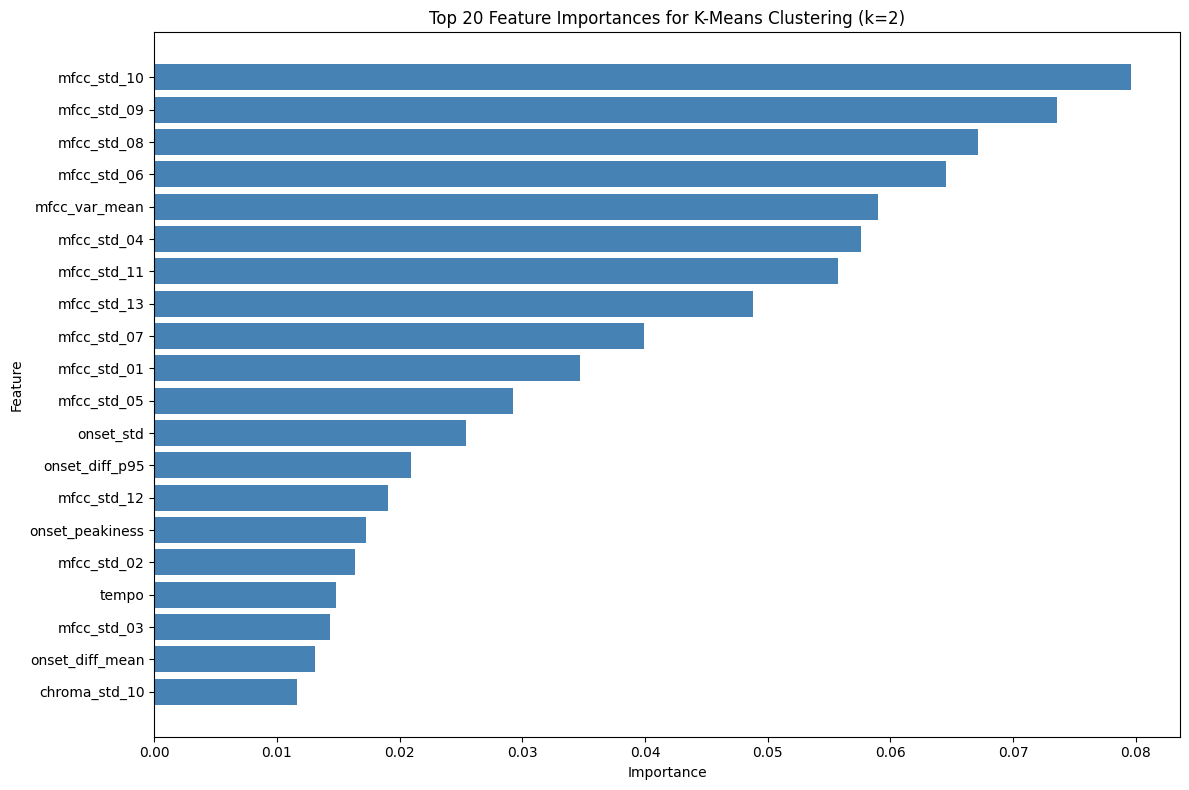

In [10]:
top_n = 20
top_features = list(feature_importances_dict.items())[:top_n]
features, importances = zip(*top_features)

plt.figure(figsize=(12, 8))
plt.barh(range(len(features)), importances, color='steelblue')
plt.yticks(range(len(features)), features)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importances for K-Means Clustering (k={chosen_k})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

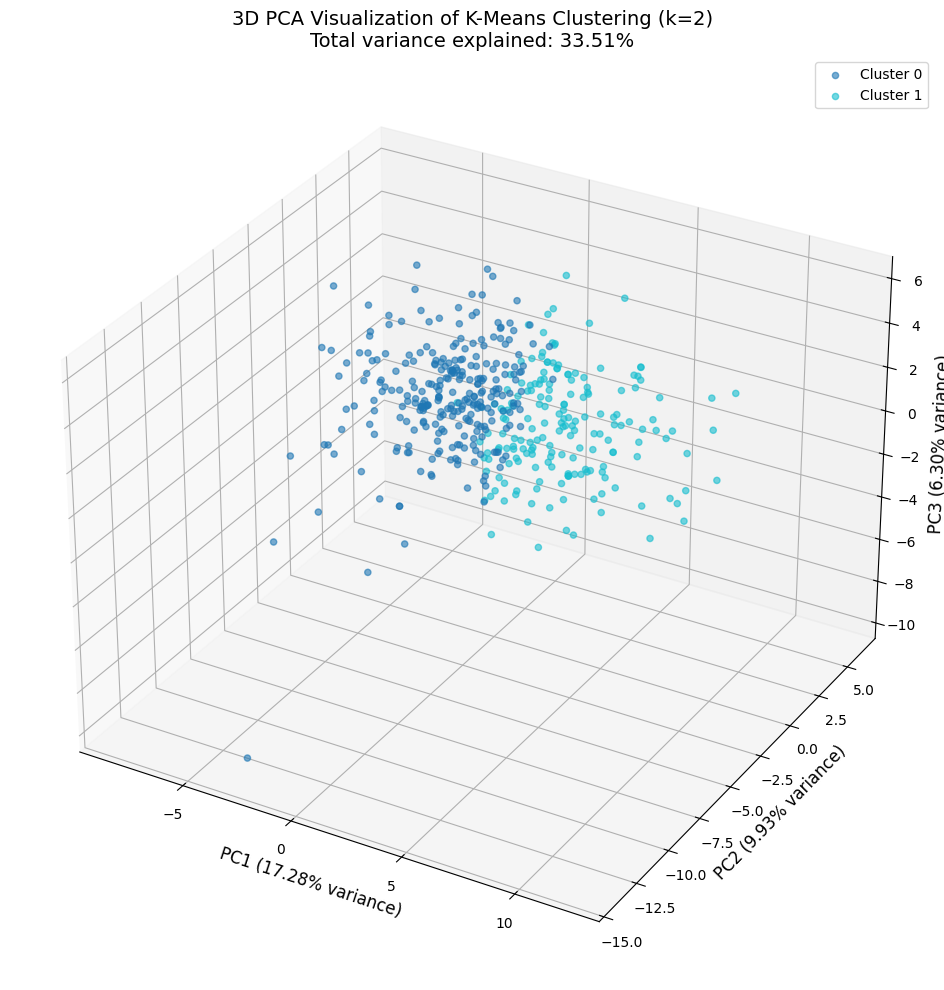

Explained variance by component: [0.17279472 0.09934691 0.06299709]
Total explained variance: 33.51%


In [11]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
pca_features = pca.fit_transform(df)

# Create 3D scatter plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Define colors for each cluster
colors = plt.cm.tab10(np.linspace(0, 1, chosen_k))

# Plot each cluster with a different color
for cluster_id in range(chosen_k):
    cluster_mask = labels == cluster_id
    ax.scatter(
        pca_features[cluster_mask, 0],
        pca_features[cluster_mask, 1],
        pca_features[cluster_mask, 2],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=20
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)', fontsize=12)
ax.set_title(f'3D PCA Visualization of K-Means Clustering (k={chosen_k})\nTotal variance explained: {pca.explained_variance_ratio_.sum():.2%}', fontsize=14)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")

## Motif Extraction
We extract motifs from each songs. This works best on 1D time series, so we transform a chosen feature to a 1D time series. We choose chroma using entropy.

In [12]:
def chroma_to_1d(out, mode="entropy"):
    C = out["chroma_bs"]  # (T, 12)
    eps = 1e-9

    if mode == "rms":
        return np.sqrt(np.mean(C**2, axis=1))
    elif mode == "entropy":
        P = C / (C.sum(axis=1, keepdims=True) + eps)
        return -(P * np.log(P + eps)).sum(axis=1)
    elif mode == "max_frac":
        P = C / (C.sum(axis=1, keepdims=True) + eps)
        return P.max(axis=1)
    else:
        return None

def normalize(x):
    x = np.asarray(x, float)
    mu = np.mean(x)
    sd = np.std(x) + 1e-9
    return (x - mu) / sd

def find_song_motifs_1d(x, m=32, top_k=3, exclusion_zone=None):
    x = np.asarray(x, float)
    if len(x) < 2 * m:
        return []

    xz = normalize(x)

    # exclusion_zone default: m//2 is typical
    if exclusion_zone is None:
        exclusion_zone = m // 2

    mp = stumpy.stump(xz, m=m, ignore_trivial=True)
    profile = mp[:, 0]     # distance to nearest neighbor
    nn_idx = mp[:, 1].astype(int)

    # candidate motifs are small profile values
    order = np.argsort(profile)
    motifs = []
    used = np.zeros_like(profile, dtype=bool)

    def mark_zone(i):
        a = max(0, i - exclusion_zone)
        b = min(len(used), i + exclusion_zone + 1)
        used[a:b] = True

    for i in order:
        if len(motifs) >= top_k:
            break
        j = nn_idx[i]
        if j < 0:
            continue
        if used[i] or used[j]:
            continue

        motifs.append((int(i), int(j), float(profile[i])))
        mark_zone(i)
        mark_zone(j)

    return motifs

signal_mode = "entropy"
m = 32 # motif length in beats

# collect motifs per cluster
cluster_motif_rows = []

for idx, row in df.reset_index(drop=True).iterrows():
    c = labels[idx]
    out = audio_features[idx]

    x = chroma_to_1d(out, mode=signal_mode)
    motifs = find_song_motifs_1d(x, m=m, top_k=3)

    for (a, b, dist) in motifs:
        # map beat indices to seconds if beat_times exist
        bt = out.get("beat_times", None)
        if bt is not None and len(bt) > max(a, b):
            a_t = float(bt[a])
            b_t = float(bt[b])
        else:
            a_t = np.nan
            b_t = np.nan

        cluster_motif_rows.append(
            {
                "cluster": c,
                "song_idx": idx,
                "motif_len_beats": m,
                "start_a_beat": a,
                "start_b_beat": b,
                "start_a_sec": a_t,
                "start_b_sec": b_t,
                "motif_dist": dist,
            }
        )

motif_df = pd.DataFrame(cluster_motif_rows)
print(motif_df.shape)
motif_df.head()

(1342, 8)


,cluster,song_idx,motif_len_beats,start_a_beat,start_b_beat,start_a_sec,start_b_sec,motif_dist
0,1,0,32,26,114,18.808163,78.808526,3.312512
1,1,0,32,1,82,1.787937,56.865669,5.345549
2,1,0,32,52,131,36.524989,90.395283,5.425802
3,0,1,32,81,179,42.353197,90.534603,2.579531
4,0,1,32,210,121,105.790113,62.020499,3.851710


### Motifs per Cluster
Create a table summarizing statistics about the motifs per cluster.

In [13]:
cluster_summary = (
    motif_df.sort_values("motif_dist")
    .groupby(["cluster", "song_idx"], as_index=False)
    .first()
    .groupby("cluster")
    .agg(
        songs_in_cluster=("song_idx", "nunique"),
        mean_best_motif_dist=("motif_dist", "mean"),
        median_best_motif_dist=("motif_dist", "median"),
    )
    .sort_values("mean_best_motif_dist")
)

cluster_summary

,songs_in_cluster,mean_best_motif_dist,median_best_motif_dist
cluster,,,
1,184,1.956792,1.773485
0,268,2.377796,2.200199


Boxplot of the best motif per cluster, measured by distance.

/tmp/ipykernel_76017/434951430.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=boxplot_labels, showfliers=False)


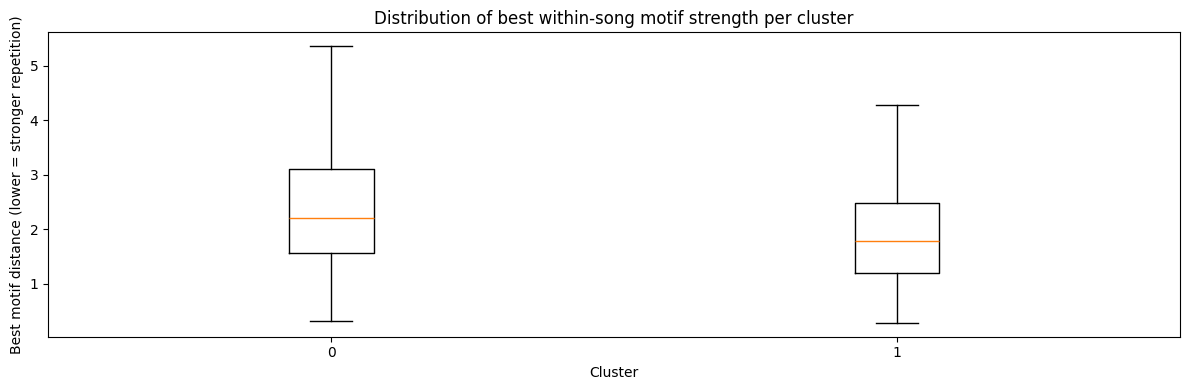

In [14]:
best_per_song = (
    motif_df.sort_values("motif_dist")
    .groupby(["cluster", "song_idx"], as_index=False)
    .first()
)

plt.figure(figsize=(12, 4))

data = [
    best_per_song.loc[best_per_song["cluster"] == c, "motif_dist"].values
    for c in sorted(best_per_song["cluster"].unique())
]
boxplot_labels = [str(c) for c in sorted(best_per_song["cluster"].unique())]

plt.boxplot(data, labels=boxplot_labels, showfliers=False)
plt.xlabel("Cluster")
plt.ylabel("Best motif distance (lower = stronger repetition)")
plt.title("Distribution of best within-song motif strength per cluster")
plt.tight_layout()
plt.show()

## Anomaly Detection
Since we already have clusters, we can use the previous cluster centers to detect anomalies in the data. We define an anomaly as a data point deviates from the typical pattern of the cluster.

First, let us resample the datapoints to a fixed time interval. This makes visualization possible.

In [15]:
def resample_ts(X, T=256):
    X = np.asarray(X, float)
    L, d = X.shape
    if L == T:
        return X
    if L < 2:
        return np.repeat(X, T, axis=0)

    old = np.linspace(0, 1, L)
    new = np.linspace(0, 1, T)
    Y = np.zeros((T, d), dtype=float)
    for j in range(d):
        Y[:, j] = np.interp(new, old, X[:, j])
    return Y

def per_song_normalize(X):
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True) + 1e-9
    return (X - mu) / sd

T = 128
d_keep = 13  # first 13 MFCCs

X_ts = []
y = [] # artist, used later for shaplets

for out in audio_features:
    X = out["mfcc_bs"][:, :d_keep]         # (n_beats, d_keep)
    X = resample_ts(X, T=T)                # (T, d_keep)
    X = per_song_normalize(X)              # normalize per song
    X_ts.append(X)
    y.append(out["artist"])

y = np.array(y)
print(y.shape)
X_ts = np.stack(X_ts, axis=0)              # (n_songs, T, d_keep)
X_ts.shape

(454,)


(454, 128, 13)

Now compute anomalies by simpy using euclidean distance between the timeseries and the cluster average

In [16]:
unique_clusters = np.sort(np.unique(labels))

# average centers
cluster_mu = {}
for c in unique_clusters:
    idx = np.where(labels == c)[0]
    cluster_mu[c] = X_ts[idx].mean(axis=0) # (T, d)

# calculate distances
scores = np.zeros((len(df), T), dtype=float)
for i in range(len(df)):
    c = labels[i]
    diff = X_ts[i] - cluster_mu[c] # (T, d)
    scores[i] = np.linalg.norm(diff, axis=1)

# normalize scores
med = np.median(scores)
mad = np.median(np.abs(scores - med)) + 1e-9
scores_z = (scores - med) / mad
scores_z.shape

(454, 128)

Now we have essentially an anomaly score at each point t in the timeseries. We can visualize the anomly level using heatmaps for each cluster.

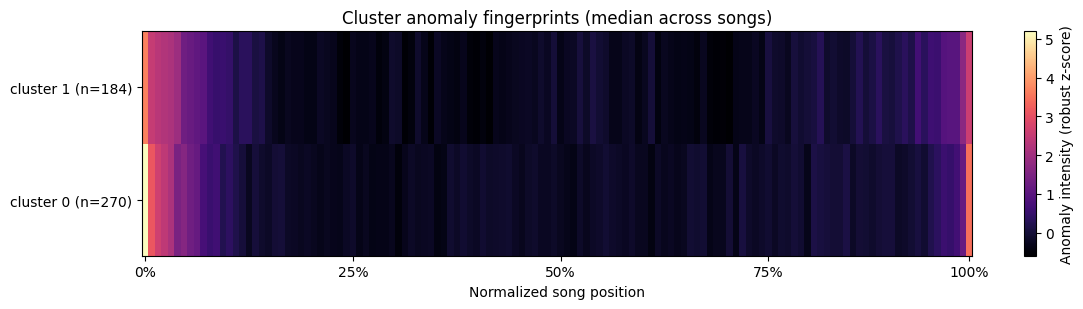

In [17]:
# aggregate per cluster: median anomaly score at each time t
cluster_fingerprint = []
cluster_sizes = []

for c in unique_clusters:
    idx = np.where(labels == c)[0]
    cluster_sizes.append(len(idx))
    cluster_fingerprint.append(np.median(scores_z[idx], axis=0))

cluster_fingerprint = np.vstack(cluster_fingerprint)  # (n_clusters, T)

plt.figure(figsize=(12, 0.6 * len(unique_clusters) + 2))
plt.imshow(cluster_fingerprint, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Anomaly intensity (robust z-score)")
plt.yticks(
    np.arange(len(unique_clusters)),
    [f"cluster {c} (n={n})" for c, n in zip(unique_clusters, cluster_sizes)],
)
plt.xticks(
    [0, T // 4, T // 2, 3 * T // 4, T - 1],
    ["0%", "25%", "50%", "75%", "100%"],
)
plt.xlabel("Normalized song position")
plt.title("Cluster anomaly fingerprints (median across songs)")
plt.tight_layout()
plt.show()

## Shapelets
For shapelets we can re-use the sampled timeseries we just created for the anomalies. We resample again to reduce training time.

In [18]:
T = 128 # aggressively reduce sample length
d_keep = 13  # first 13 MFCCs

X_ts = []
y = [] # artist, used later for shaplets

for out in audio_features:
    X = out["mfcc_bs"][:, :d_keep]         # (n_beats, d_keep)
    X = resample_ts(X, T=T)                # (T, d_keep)
    X = per_song_normalize(X)              # normalize per song
    X_ts.append(X)
    y.append(out["artist"])

y = np.array(y)
print(y.shape)
X_ts = np.stack(X_ts, axis=0)              # (n_songs, T, d_keep)
print(X_ts.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_ts, y, test_size=0.2, stratify=y
)

shapelet_sizes = {16: 2, 32: 1}

clf = LearningShapelets(
    n_shapelets_per_size=shapelet_sizes,
    optimizer="adam",
    batch_size=64,
    weight_regularizer=1e-3,
    max_iter=50,
    verbose=1,
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["ART07024718", "ART25707984"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

/home/faxy/Documents/UniPi/Projects/DM/jupyter_env/lib/python3.12/site-packages/tslearn/shapelets/shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "


(454,)
(454, 128, 13)


2025-12-31 17:21:32.207166: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/faxy/Documents/UniPi/Projects/DM/jupyter_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/50


/home/faxy/Documents/UniPi/Projects/DM/jupyter_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/home/faxy/Documents/UniPi/Projects/DM/jupyter_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 4.4251 - loss: 4.4262
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 4.3142 - loss: 4.3152
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 4.2034 - loss: 4.2045
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 4.0949 - loss: 4.0960
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 3.9849 - loss: 3.9860
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 3.8770 - loss: 3.8781
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 3.7720 - loss: 3.7730
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.3939 - binary_crossentropy: 3.6690 - loss: 3.6700
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - 

/home/faxy/Documents/UniPi/Projects/DM/jupyter_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/home/faxy/Documents/UniPi/Projects/DM/jupyter_env/lib/python3.12/site-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'min_pooling_1' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


              precision    recall  f1-score   support

 ART07024718       0.37      0.67      0.48        36
 ART25707984       0.54      0.25      0.35        55

    accuracy                           0.42        91
   macro avg       0.45      0.46      0.41        91
weighted avg       0.47      0.42      0.40        91

Confusion matrix:
 [[24 12]
 [41 14]]


Plot the learned shapelets.

Num shapelets: 3
Example shapelet shape: (16, 13)


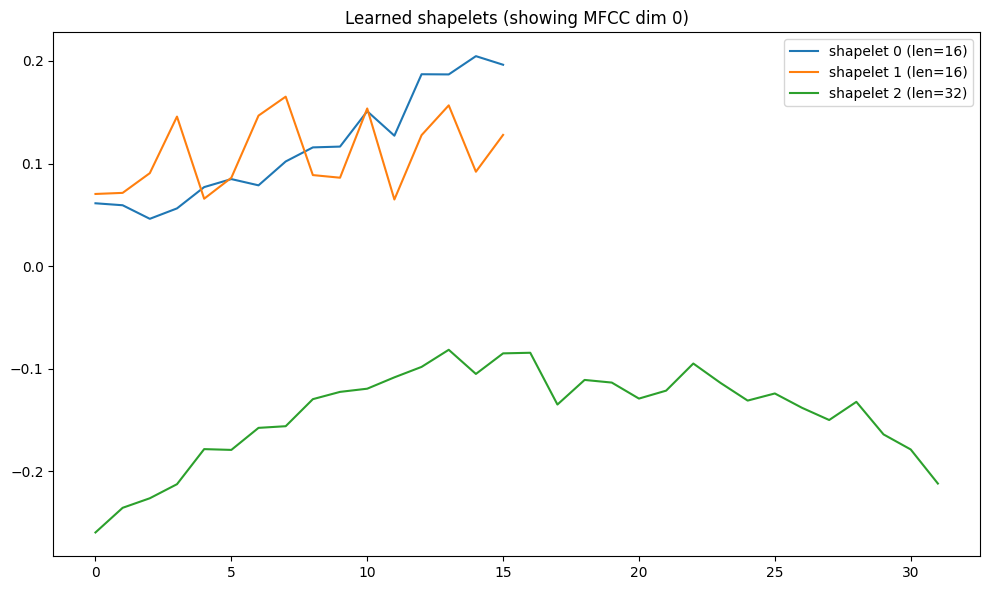

In [19]:
shapelets = clf.shapelets_

print("Num shapelets:", len(shapelets))
print("Example shapelet shape:", shapelets[0].shape)

n_plot = len(shapelets)
mfcc_dim = 0  # plot MFCC-1 by default

plt.figure(figsize=(10, 6))
for i in range(n_plot):
    s = shapelets[i][:, mfcc_dim]
    plt.plot(s, label=f"shapelet {i} (len={shapelets[i].shape[0]})")
plt.title(f"Learned shapelets (showing MFCC dim {mfcc_dim})")
plt.legend()
plt.tight_layout()
plt.show()

Match the shaplet back to the most probable location in the songs.

In [20]:
def best_match_location(song_ts, shapelet):

    T, d = song_ts.shape
    L, d2 = shapelet.shape
    assert d == d2
    best_dist = np.inf
    best_start = 0

    for start in range(0, T - L + 1):
        window = song_ts[start : start + L]
        dist = np.linalg.norm(window - shapelet)
        if dist < best_dist:
            best_dist = dist
            best_start = start
    return best_start, best_dist

def match_all_shapelets(X_ts, shapelets, top_k_songs=10):
    rows = []
    for sh_id, sh in enumerate(shapelets):
        for song_idx in range(len(X_ts)):
            start, dist = best_match_location(X_ts[song_idx], sh)
            rows.append(
                {
                    "shapelet_id": sh_id,
                    "shapelet_len": sh.shape[0],
                    "song_idx": song_idx,
                    "start_T": start,
                    "dist": dist,
                    "artist": audio_features[song_idx]["artist"],
                }
            )

    dfm = pd.DataFrame(rows)

    # for each shapelet, keep only the top-k closest songs (best matches)
    df_top = (
        dfm.sort_values(["shapelet_id", "dist"], ascending=[True, True])
        .groupby("shapelet_id")
        .head(top_k_songs)
        .reset_index(drop=True)
    )
    return dfm, df_top


df_all_matches, df_top_matches = match_all_shapelets(
    X_ts=X_ts, shapelets=shapelets, top_k_songs=10
)

df_top_matches.head(20)

,shapelet_id,shapelet_len,song_idx,start_T,dist,artist
0,0,16,402,87,7.604021,ART25707984
1,0,16,270,72,7.750517,ART25707984
2,0,16,275,40,8.026364,ART25707984
3,0,16,325,77,8.040112,ART25707984
4,0,16,162,54,8.050151,ART07024718
5,0,16,368,88,8.062032,ART25707984
6,0,16,329,88,8.078078,ART25707984
7,0,16,3,72,8.105594,ART07024718
8,0,16,193,65,8.122228,ART25707984
9,0,16,266,98,8.122966,ART25707984


Which artist prefers which shaplet?




In [22]:
summary = (
    df_top_matches.groupby(["shapelet_id", "shapelet_len", "artist"])
    .size()
    .unstack(fill_value=0)
)
summary["dominance"] = summary.max(axis=1) / summary.sum(axis=1)
shapelet_artist_match_df = summary.sort_values("dominance", ascending=False)
display(shapelet_artist_match_df)

,artist,ART07024718,ART25707984,dominance
shapelet_id,shapelet_len,,,
0,16,2,8,0.8
1,16,2,8,0.8
2,32,2,8,0.8
